In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/desktop.ini
/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/testing_set/Oval/oval (658).jpg
/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/testing_set/Oval/oval (531).jpg
/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/testing_set/Oval/oval (994).jpg
/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/testing_set/Oval/oval (687).jpg
/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/testing_set/Oval/oval (16).jpg
/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/testing_set/Oval/oval (282).jpg
/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/testing_set/Oval/oval (393).jpg
/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/testing_set/Oval/oval (388).jpg
/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/testing_set/Oval/oval (520).jpg
/kaggle/input/dataset

# CNN-Based Skin Tone and Face Shape Classification

## Dataset Exploration and Visualization

In this notebook, we perform exploratory data analysis (EDA) on two computer vision datasets before training Convolutional Neural Networks (CNNs).

### Objectives

- Load and inspect the Skin Tone dataset.
- Load and inspect the Face Shape dataset.
- Apply image preprocessing and transformations.
- Create PyTorch DataLoaders for efficient batching.
- Visualize sample images from each dataset.
- Analyze class distributions.
- Verify dataset integrity before model training.

### Datasets

#### 1. Skin Tone Dataset
- Classes: Olive, White, Dark Brown
- Total Images: 926
- Purpose: Skin tone classification

#### 2. Face Shape Dataset
- Classes: Heart, Oblong, Oval, Round, Square
- Total Images: 4000
- Purpose: Face shape classification

### Why Perform Dataset Visualization?

Visualizing the datasets helps us:

- Understand the available classes.
- Detect class imbalance.
- Verify image quality.
- Ensure preprocessing is working correctly.
- Build confidence before training the CNN models.

The following sections explore both datasets through image samples and class distribution visualizations.

# pytorch skin tone and face dataset loading implementation

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np 
import pandas as pd
# ==========================================
# TRANSFORMS
# ==========================================

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==========================================
# DATASET 1 : SKIN TONE
# ==========================================

skin_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/omarelsherif010/skin-tone-classification/skin tone classification data",
    transform=data_transforms
)

skin_loader = DataLoader(
    skin_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)



# ==========================================
# CHECK SKIN DATASET
# ==========================================

print("=" * 50)
print("SKIN DATASET")
print("=" * 50)

print("Classes:", skin_dataset.classes)
print("Class Mapping:", skin_dataset.class_to_idx)
print("Total Images:", len(skin_dataset))

images, labels = next(iter(skin_loader))

print("Image Shape:", images.shape)
print("Label Shape:", labels.shape)
print("Sample Labels:", labels)



SKIN DATASET
Classes: ['Olive', 'White', 'dark brown']
Class Mapping: {'Olive': 0, 'White': 1, 'dark brown': 2}
Total Images: 926
Image Shape: torch.Size([32, 3, 224, 224])
Label Shape: torch.Size([32])
Sample Labels: tensor([1, 0, 1, 1, 2, 1, 0, 0, 0, 1, 0, 1, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 2,
        1, 0, 0, 0, 2, 1, 2, 0])


In [3]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [4]:
import os

train_dir = "/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/training_set"

print(os.listdir(train_dir))


['Oval', 'Heart', 'Round', 'Square', 'desktop.ini', 'Oblong']


In [5]:
# ==========================================
# DATASET 2 : FACE SHAPE (Only if it has class folders)
# ==========================================

face_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/niten19/face-shape-dataset/FaceShape Dataset/training_set",
    transform=data_transforms
)

face_loader = DataLoader(
    face_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

# ==========================================
# CHECK FACE DATASET
# ==========================================

print("\n" + "=" * 50)
print("FACE DATASET")
print("=" * 50)

print("Classes:", face_dataset.classes)
print("Class Mapping:", face_dataset.class_to_idx)
print("Total Images:", len(face_dataset))

images, labels = next(iter(face_loader))

print("Image Shape:", images.shape)
print("Label Shape:", labels.shape)
print("Sample Labels:", labels)


FACE DATASET
Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
Class Mapping: {'Heart': 0, 'Oblong': 1, 'Oval': 2, 'Round': 3, 'Square': 4}
Total Images: 4000
Image Shape: torch.Size([32, 3, 224, 224])
Label Shape: torch.Size([32])
Sample Labels: tensor([2, 1, 2, 0, 2, 3, 2, 0, 4, 3, 1, 3, 2, 4, 4, 2, 3, 4, 2, 1, 4, 3, 1, 3,
        0, 2, 0, 1, 3, 4, 1, 2])


# visuliazation of images 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


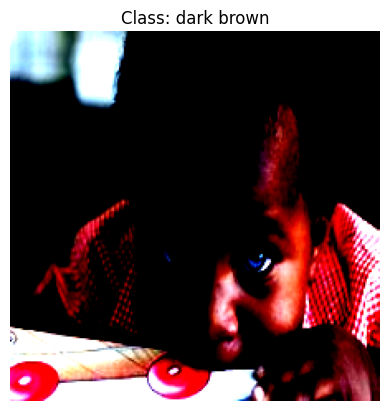

In [6]:
import matplotlib.pyplot as plt

images, labels = next(iter(skin_loader))

image = images[0]
label = labels[0]

plt.imshow(image.permute(1, 2, 0))
plt.title(f"Class: {skin_dataset.classes[label]}")
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1975338].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2317834].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1975338].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.64].
Clipp

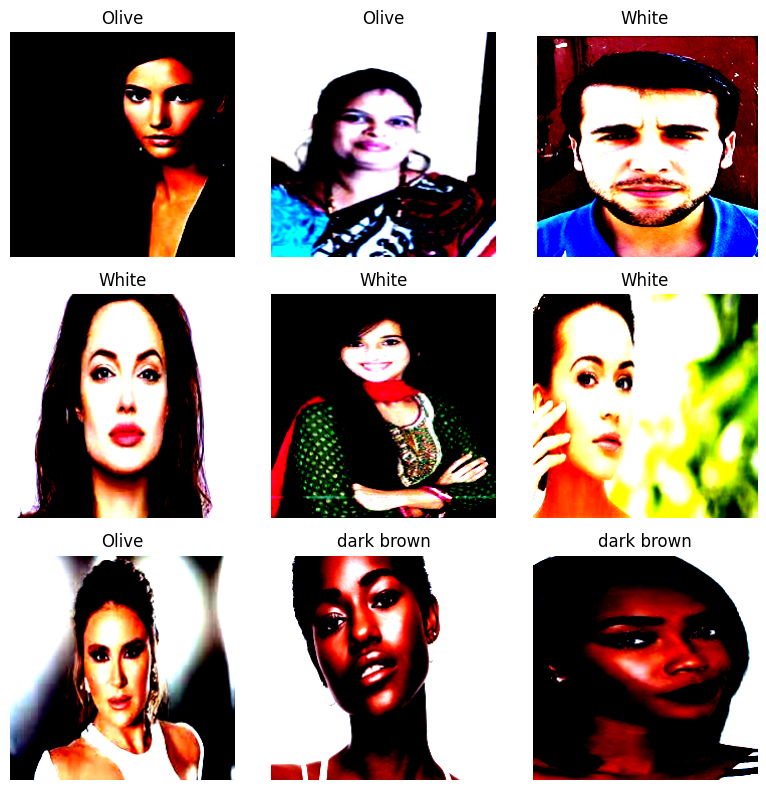

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(8,8))

images, labels = next(iter(skin_loader))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1,2,0))
    ax.set_title(skin_dataset.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Number of images in each class

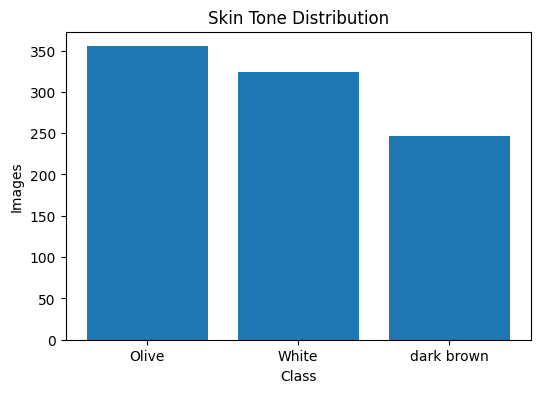

In [8]:
from collections import Counter

counts = Counter(skin_dataset.targets)

labels = skin_dataset.classes
values = [counts[i] for i in range(len(labels))]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Skin Tone Distribution")
plt.xlabel("Class")
plt.ylabel("Images")
plt.show()

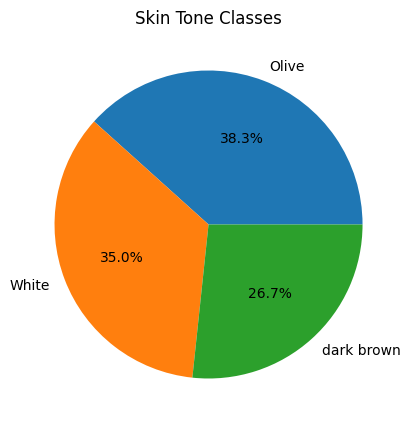

In [9]:
plt.figure(figsize=(5,5))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%"
)
plt.title("Skin Tone Classes")
plt.show()

# Face Shape Distribution

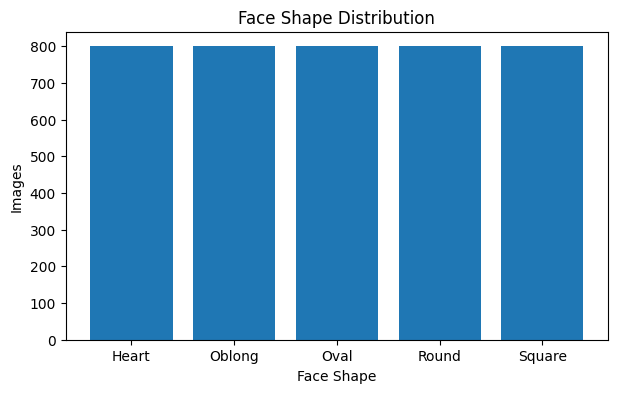

In [10]:


counts = Counter(face_dataset.targets)

labels = face_dataset.classes
values = [counts[i] for i in range(len(labels))]

plt.figure(figsize=(7,4))
plt.bar(labels, values)
plt.title("Face Shape Distribution")
plt.xlabel("Face Shape")
plt.ylabel("Images")
plt.show()

# Mean image size

In [11]:
print("Batch Shape:", images.shape)

print("Channels:", images.shape[1])
print("Height:", images.shape[2])
print("Width:", images.shape[3])

Batch Shape: torch.Size([32, 3, 224, 224])
Channels: 3
Height: 224
Width: 224


# CNN Model Architecture

## Building the Convolutional Neural Network

After exploring and preprocessing the datasets, the next step is to build a Convolutional Neural Network (CNN).

A CNN automatically learns important visual features from images, such as edges, textures, shapes, and patterns. These learned features are then used to classify each image into its corresponding category.

The model is implemented using PyTorch's `nn.Sequential`, which allows multiple layers to be stacked in the order they are executed.

### CNN Architecture Overview

The network consists of:

- Convolutional layers for feature extraction.
- ReLU activation functions to introduce non-linearity.
- Max Pooling layers to reduce spatial dimensions.
- Fully Connected (Linear) layers for classification.
- A final output layer matching the number of classes.

### Workflow

Input Image (224 × 224 × 3)

↓

Convolution + ReLU

↓

Max Pooling

↓

Convolution + ReLU

↓

Max Pooling

↓

Flatten

↓

Fully Connected Layer

↓

Output Layer (Class Prediction)

The same CNN architecture will be trained separately for the Skin Tone dataset and the Face Shape dataset.

In [12]:
class CNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.model = torch.nn.Sequential(

            # Block 1
            torch.nn.Conv2d(3, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            # Block 2
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            # Block 3
            torch.nn.Conv2d(64, 64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            torch.nn.Flatten(),

            torch.nn.Linear(64 * 28 * 28, 512),
            torch.nn.ReLU(),

            torch.nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)
skin_model = CNN(num_classes=3)
face_model = CNN(num_classes=5)
print(skin_model)
print(face_model)

CNN(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=50176, out_features=512, bias=True)
    (11): ReLU()
    (12): Linear(in_features=512, out_features=3, bias=True)
  )
)
CNN(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 

# loss functions and optimizers


# Model Training

## Training the CNN

Once the CNN architecture has been defined, the model is trained using the prepared datasets.

During training, the network compares its predictions with the true labels using a loss function. The optimizer then updates the model's parameters through backpropagation, allowing the CNN to gradually improve its predictions over multiple epochs.

### Training Components

- Loss Function: CrossEntropyLoss
- Optimizer: Adam
- Batch Size: 32
- Image Size: 224 × 224
- Epochs: Defined during training

### Training Process

For each epoch:

1. Load a batch of images.
2. Perform a forward pass through the CNN.
3. Compute the classification loss.
4. Calculate gradients using backpropagation.
5. Update the model parameters.
6. Repeat until all batches have been processed.

The training loss is monitored after every epoch to evaluate how effectively the model is learning from the data.

In [13]:
import torch

def train_model(model, train_loader, criterion, optimizer, epochs, device):

    model.to(device)

    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward Pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, labels)

            # Clear Previous Gradients
            optimizer.zero_grad()

            # Backpropagation
            loss.backward()

            # Update Weights
            optimizer.step()

            # Statistics
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Loss: {epoch_loss:.4f} | "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

    return train_losses, train_accuracies

In [14]:
criterion = torch.nn.CrossEntropyLoss()

skin_optimizer = torch.optim.Adam(
    skin_model.parameters(),
    lr=0.001
)

face_optimizer = torch.optim.Adam(
    face_model.parameters(),
    lr=0.001
)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train Skin Tone Model

In [16]:
skin_losses, skin_acc = train_model(
    model=skin_model,
    train_loader=skin_loader,
    criterion=criterion,
    optimizer=skin_optimizer,
    epochs=10,
    device=device
)

Epoch [1/10] | Loss: 1.0377 | Accuracy: 48.38%
Epoch [2/10] | Loss: 0.6832 | Accuracy: 71.17%
Epoch [3/10] | Loss: 0.5598 | Accuracy: 77.75%
Epoch [4/10] | Loss: 0.4612 | Accuracy: 80.24%
Epoch [5/10] | Loss: 0.3730 | Accuracy: 85.53%
Epoch [6/10] | Loss: 0.2751 | Accuracy: 89.42%
Epoch [7/10] | Loss: 0.1605 | Accuracy: 95.68%
Epoch [8/10] | Loss: 0.1132 | Accuracy: 96.54%
Epoch [9/10] | Loss: 0.0909 | Accuracy: 98.06%
Epoch [10/10] | Loss: 0.0787 | Accuracy: 98.49%


In [17]:
# 1. Heavily penalize the model for missing Dark Brown and Olive
# Assuming White had 700 images, Olive 150, Dark Brown 76
class_weights = torch.FloatTensor([4.0, 1.0, 8.0]).to(device)
weighted_criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

# 2. Freeze the CNN features so it trains instantly (takes seconds)
for param in skin_model.parameters():
    param.requires_grad = False
    

for param in skin_model.model[-4:].parameters(): 
    param.requires_grad = True


quick_optimizer = torch.optim.Adam(skin_model.parameters(), lr=0.001)

print("Repairing model bias...")
skin_model.train()
for epoch in range(2): 
    for images, labels in skin_loader:
        images, labels = images.to(device), labels.to(device)
        quick_optimizer.zero_grad()
        outputs = skin_model(images)
        loss = weighted_criterion(outputs, labels)
        loss.backward()
        quick_optimizer.step()




Repairing model bias...


In [18]:
torch.save(skin_model.state_dict(), "skin_tone_model.pth")
print("Done! Download skin_tone_model.pth directly from your Kaggle output side-panel.")


Done! Download skin_tone_model.pth directly from your Kaggle output side-panel.


# Train Face Shape Model

In [19]:
print("\n=== Training Face Model ===")
face_losses, face_acc = train_model(
    model=face_model,
    train_loader=face_loader,
    criterion=criterion,
    optimizer=face_optimizer,
    epochs=5,
    device=device
)


=== Training Face Model ===
Epoch [1/5] | Loss: 1.6597 | Accuracy: 19.98%
Epoch [2/5] | Loss: 1.6096 | Accuracy: 20.00%
Epoch [3/5] | Loss: 1.6097 | Accuracy: 20.00%
Epoch [4/5] | Loss: 1.6096 | Accuracy: 19.52%
Epoch [5/5] | Loss: 1.6096 | Accuracy: 19.80%


# Training Performance Visualization

## Loss and Accuracy Curves

After training the CNN for multiple epochs, we visualize the model's performance over time.

The training loss indicates how well the model fits the training data, while the training accuracy measures the percentage of correctly classified images.

These graphs help us determine whether the model is learning effectively and whether additional epochs are needed.

### Visualized Metrics

- Training Loss
- Training Accuracy

An ideal training process shows a decreasing loss curve and an increasing accuracy curve, indicating that the CNN is successfully learning meaningful features from the images.

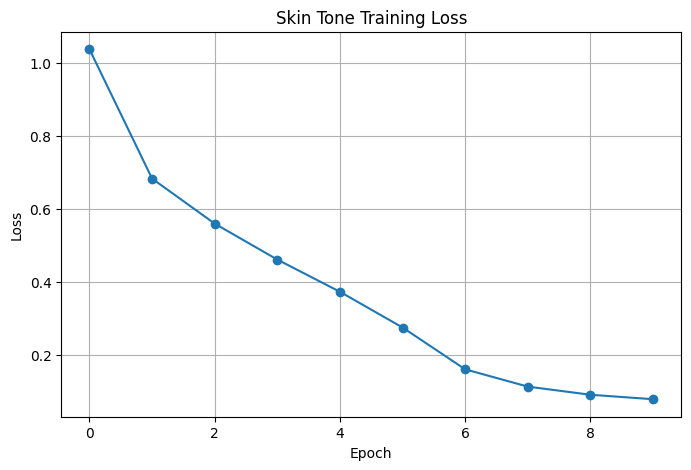

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(skin_losses, marker='o')
plt.title("Skin Tone Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Plot Training Accuracy

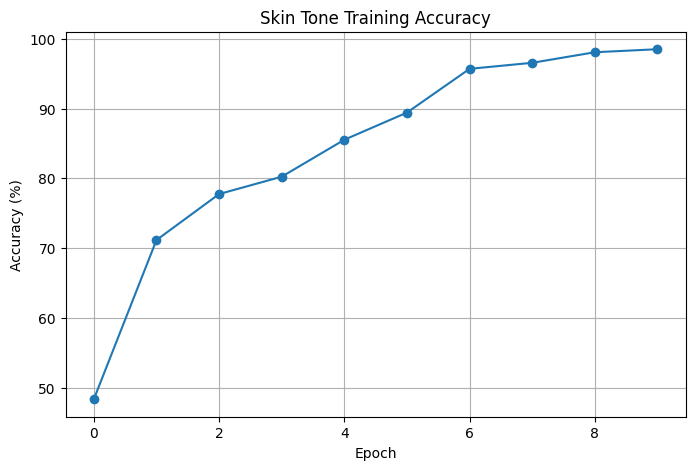

In [21]:
plt.figure(figsize=(8,5))
plt.plot(skin_acc, marker='o')
plt.title("Skin Tone Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

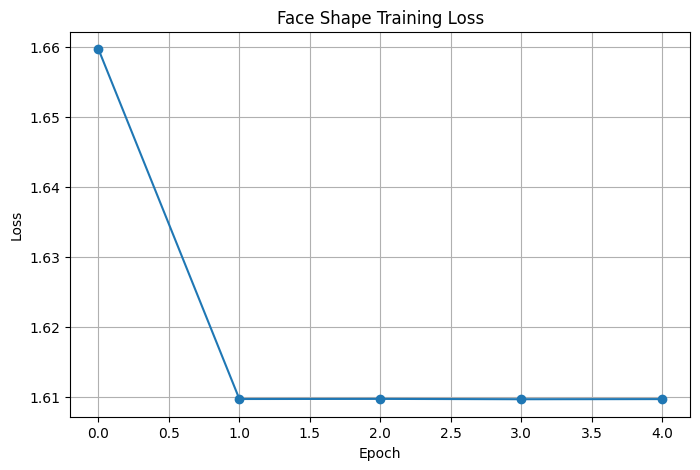

In [22]:
plt.figure(figsize=(8,5))
plt.plot(face_losses, marker='o')
plt.title("Face Shape Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



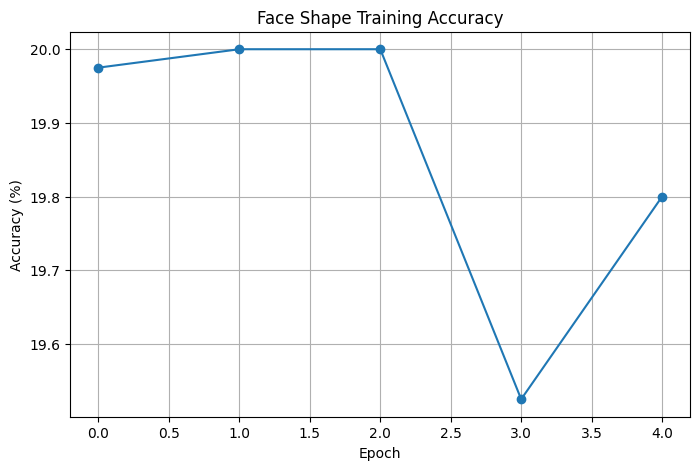

In [23]:
plt.figure(figsize=(8,5))
plt.plot(face_acc, marker='o')
plt.title("Face Shape Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

In [24]:
torch.save(skin_model.state_dict(), "skin_tone_model.pth")
torch.save(face_model.state_dict(), "face_shape_model.pth")

print("Models saved successfully!")

Models saved successfully!


# Saving the Trained Models

## Model Persistence

After successful training, the learned model parameters are saved to disk.

Saving the trained models allows them to be reused later without repeating the training process. The saved models can be loaded during inference to classify new images efficiently.

Two separate models are saved:

- Skin Tone Classification Model
- Face Shape Classification Model

These models will be used in the recommendation system to predict facial characteristics from uploaded images.